# Nome: Alessandro da Silva Maciel
# Matrícula: aluno especial

## Import all packages need in the cell below

In [1]:
using LinearAlgebra
using Plots
using Optim
using NLsolve
using ForwardDiff
using AutoGrad

## FONC example

Plot the graphics of $f(x) = (x_1 - 3)^2 + (x_2 + 4)^2$

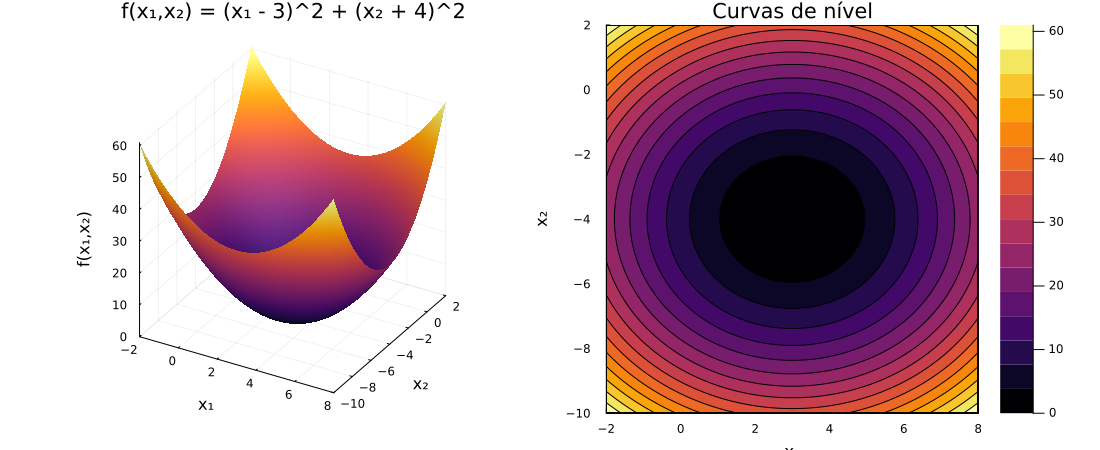

In [2]:
# FONC example
# Plot the graphics of f(x) = (x1 - 3)^2 + (x2 + 4)^2

f_plot(x1, x2) = (x1 - 3)^2 + (x2 + 4)^2

x1_vals = -2.0:0.1:8.0
x2_vals = -10.0:0.1:2.0

Z = [f_plot(x1, x2) for x2 in x2_vals, x1 in x1_vals]

p1 = surface(
    x1_vals, x2_vals, Z,
    xlabel = "x₁",
    ylabel = "x₂",
    zlabel = "f(x₁,x₂)",
    title = "f(x₁,x₂) = (x₁ - 3)^2 + (x₂ + 4)^2",
    legend = false
)

p2 = contour(
    x1_vals, x2_vals, Z,
    xlabel = "x₁",
    ylabel = "x₂",
    title = "Curvas de nível",
    fill = true
)

plot(p1, p2, layout = (1, 2), size = (1100, 450))

## Solving the FONC

Given the function $z = (x_1 - 1)^4 + (x_2 - 2)^4$:

* using the optim.jl package, find the minimum of z.
* using the NLsolve.jl package, solve the FONC problem for this function

In [3]:
# Solving the FONC
# z = (x1 - 1)^4 + (x2 - 2)^4
# Parte 1: encontrar o mínimo com Optim.jl

z(x) = (x[1] - 1)^4 + (x[2] - 2)^4

x0 = [-3.0, 5.0]   # chute inicial

res_optim = optimize(z, x0, BFGS(); autodiff = :forward)

xmin_optim = Optim.minimizer(res_optim)
zmin_optim = Optim.minimum(res_optim)

println("=== Resultado com Optim.jl ===")
println("Minimizador = ", xmin_optim)
println("Valor mínimo = ", zmin_optim)
println("Status = ", Optim.converged(res_optim))
println(res_optim)

=== Resultado com Optim.jl ===
Minimizador = [0.999690766542646, 2.0004062258006354]
Valor mínimo = 3.637560669702326e-14
Status = true
 * Status: success

 * Candidate solution
    Final objective value:     3.637561e-14

 * Found with
    Algorithm:     BFGS

 * Convergence measures
    |x - x'|               = 4.08e-03 ≰ 0.0e+00
    |x - x'|/|x'|          = 2.04e-03 ≰ 0.0e+00
    |f(x) - f(x')|         = 6.95e-10 ≰ 0.0e+00
    |f(x) - f(x')|/|f(x')| = 1.91e+04 ≰ 0.0e+00
    |g(x)|                 = 2.68e-10 ≤ 1.0e-08

 * Work counters
    Seconds run:   0  (vs limit Inf)
    Iterations:    12
    f(x) calls:    50
    ∇f(x) calls:   50



In [4]:
# Parte 2: resolver a FONC com NLsolve.jl
# FONC: ∇z(x) = 0
# ∂z/∂x1 = 4(x1 - 1)^3
# ∂z/∂x2 = 4(x2 - 2)^3

function fonc_system!(F, x)
    F[1] = 4 * (x[1] - 1)^3
    F[2] = 4 * (x[2] - 2)^3
end

x0_fonc = [-3.0, 5.0]

res_nl = nlsolve(fonc_system!, x0_fonc)

xmin_fonc = res_nl.zero
zmin_fonc = z(xmin_fonc)

println("\n=== Resultado com NLsolve.jl ===")
println("Solução da FONC = ", xmin_fonc)
println("Valor da função na solução = ", zmin_fonc)
println("Convergiu? ", converged(res_nl))
println(res_nl)


=== Resultado com NLsolve.jl ===
Solução da FONC = [0.998797081296274, 2.0009022077047214]
Valor da função na solução = 2.756409195451915e-12
Convergiu? true
Results of Nonlinear Solver Algorithm
 * Algorithm: Trust-region with dogleg and autoscaling
 * Starting Point: [-3.0, 5.0]
 * Zero: [0.998797081296274, 2.0009022077047214]
 * Inf-norm of residuals: 0.000000
 * Iterations: 20
 * Convergence: true
   * |x - x'| < 0.0e+00: false
   * |f(x)| < 1.0e-08: true
 * Function Calls (f): 21
 * Jacobian Calls (df/dx): 21


In [5]:
# Conferência final

println("\n=== Conferência ===")
println("Solução esperada: x* = [1, 2]")
println("Optim.jl  -> x* = ", xmin_optim, ", z* = ", zmin_optim)
println("NLsolve.jl -> x* = ", xmin_fonc, ", z* = ", zmin_fonc)


=== Conferência ===
Solução esperada: x* = [1, 2]
Optim.jl  -> x* = [0.999690766542646, 2.0004062258006354], z* = 3.637560669702326e-14
NLsolve.jl -> x* = [0.998797081296274, 2.0009022077047214], z* = 2.756409195451915e-12


Plot the level curve and the graphics of $f(x) = (x_1 - 3)^2 + (x_2 - 2)^2$

=== Problema 1 ===
Ponto inicial = [1.0, 1.0]
Gradient Descent -> xmin = [3.0, 2.0], f(xmin) = 0.0, iterações = 1
Newton          -> xmin = [3.0, 2.0], f(xmin) = 0.0, iterações = 1


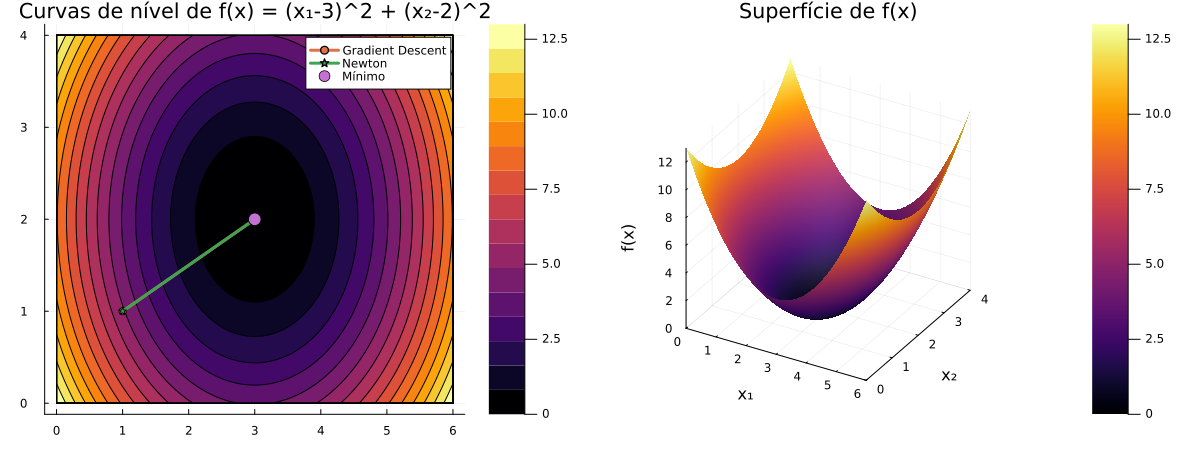

In [6]:
# =========================
# Funções auxiliares
# =========================

# Backtracking line search (Armijo)
function backtracking(f, x, d; α=0.25, β=0.5, t0=1.0)
    t = t0
    g = ForwardDiff.gradient(f, x)
    fx = f(x)
    while f(x + t*d) > fx + α*t*dot(g, d)
        t *= β
    end
    return t
end

# Gradient Descent
function gradient_descent(f, x0; tol=1e-8, maxiter=200, α=0.25, β=0.5)
    x = copy(x0)
    xs = [copy(x)]
    fs = [f(x)]

    for k in 1:maxiter
        g = ForwardDiff.gradient(f, x)
        if norm(g) < tol
            break
        end
        d = -g
        t = backtracking(f, x, d; α=α, β=β, t0=1.0)
        x = x + t*d
        push!(xs, copy(x))
        push!(fs, f(x))
    end

    return x, xs, fs
end

# Newton
function newton_method(f, x0; tol=1e-8, maxiter=50, α=0.25, β=0.5)
    x = copy(x0)
    xs = [copy(x)]
    fs = [f(x)]

    for k in 1:maxiter
        g = ForwardDiff.gradient(f, x)
        H = ForwardDiff.hessian(f, x)

        if norm(g) < tol
            break
        end

        d = -(H \ g)   # resolve H*d = -g
        t = backtracking(f, x, d; α=α, β=β, t0=1.0)
        x = x + t*d

        push!(xs, copy(x))
        push!(fs, f(x))
    end

    return x, xs, fs
end

# Converte trajetória para vetores x1 e x2
function split_path(xs)
    x1 = [x[1] for x in xs]
    x2 = [x[2] for x in xs]
    return x1, x2
end

# =========================
# Problema 1
# =========================

f1(x) = (x[1] - 3)^2 + (x[2] - 2)^2
x0 = [1.0, 1.0]

xmin_gd_1, xs_gd_1, fs_gd_1 = gradient_descent(f1, x0)
xmin_nt_1, xs_nt_1, fs_nt_1 = newton_method(f1, x0)

println("=== Problema 1 ===")
println("Ponto inicial = ", x0)
println("Gradient Descent -> xmin = ", xmin_gd_1, ", f(xmin) = ", f1(xmin_gd_1), ", iterações = ", length(xs_gd_1)-1)
println("Newton          -> xmin = ", xmin_nt_1, ", f(xmin) = ", f1(xmin_nt_1), ", iterações = ", length(xs_nt_1)-1)

# Malha para gráficos
x1v = 0.0:0.05:6.0
x2v = 0.0:0.05:4.0
Z1 = [f1([x1, x2]) for x2 in x2v, x1 in x1v]

gd_x1_1, gd_x2_1 = split_path(xs_gd_1)
nt_x1_1, nt_x2_1 = split_path(xs_nt_1)

p1 = contour(
    x1v, x2v, Z1;
    fill=true,
    xlabel="x₁", ylabel="x₂",
    title="Curvas de nível de f(x) = (x₁-3)^2 + (x₂-2)^2"
)
plot!(p1, gd_x1_1, gd_x2_1, lw=3, marker=:circle, label="Gradient Descent")
plot!(p1, nt_x1_1, nt_x2_1, lw=3, marker=:star5, label="Newton")
scatter!(p1, [3.0], [2.0], markersize=7, label="Mínimo")

p2 = surface(
    x1v, x2v, Z1;
    xlabel="x₁", ylabel="x₂", zlabel="f(x)",
    title="Superfície de f(x)"
)

plot(p1, p2, layout=(1,2), size=(1200,450))

=== Problema 2 ===
Ponto inicial = [1.0, 1.0]
Gradient Descent -> xmin = [2.9999999995343387, 2.0], f(xmin) = 2.168404344971009e-18, iterações = 18
Newton          -> xmin = [3.0, 2.0], f(xmin) = 0.0, iterações = 1


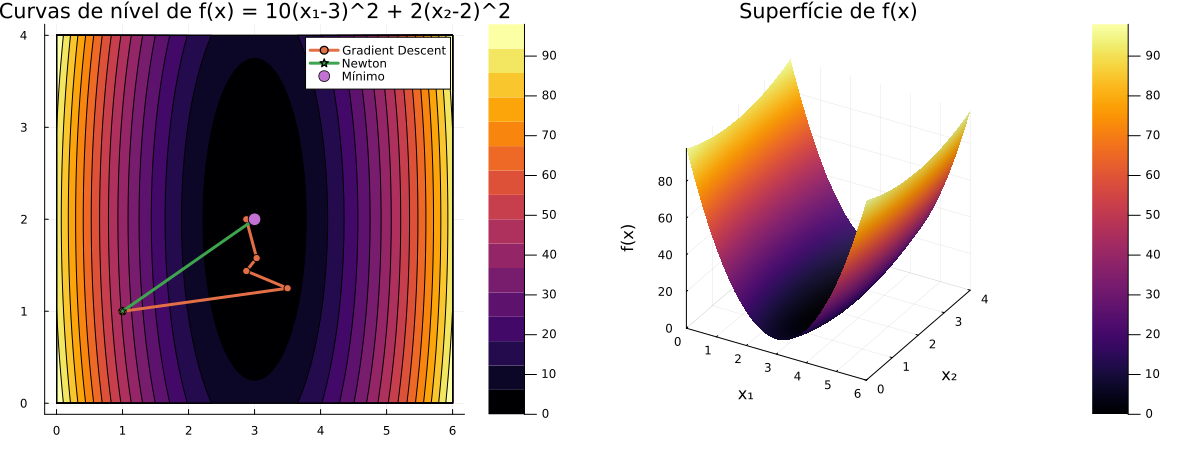

In [7]:
# =========================
# Problema 2
# =========================

f2(x) = 10*(x[1] - 3)^2 + 2*(x[2] - 2)^2
x0 = [1.0, 1.0]

xmin_gd_2, xs_gd_2, fs_gd_2 = gradient_descent(f2, x0)
xmin_nt_2, xs_nt_2, fs_nt_2 = newton_method(f2, x0)

println("=== Problema 2 ===")
println("Ponto inicial = ", x0)
println("Gradient Descent -> xmin = ", xmin_gd_2, ", f(xmin) = ", f2(xmin_gd_2), ", iterações = ", length(xs_gd_2)-1)
println("Newton          -> xmin = ", xmin_nt_2, ", f(xmin) = ", f2(xmin_nt_2), ", iterações = ", length(xs_nt_2)-1)

# Malha para gráficos
x1v = 0.0:0.05:6.0
x2v = 0.0:0.05:4.0
Z2 = [f2([x1, x2]) for x2 in x2v, x1 in x1v]

gd_x1_2, gd_x2_2 = split_path(xs_gd_2)
nt_x1_2, nt_x2_2 = split_path(xs_nt_2)

p3 = contour(
    x1v, x2v, Z2;
    fill=true,
    xlabel="x₁", ylabel="x₂",
    title="Curvas de nível de f(x) = 10(x₁-3)^2 + 2(x₂-2)^2"
)
plot!(p3, gd_x1_2, gd_x2_2, lw=3, marker=:circle, label="Gradient Descent")
plot!(p3, nt_x1_2, nt_x2_2, lw=3, marker=:star5, label="Newton")
scatter!(p3, [3.0], [2.0], markersize=7, label="Mínimo")

p4 = surface(
    x1v, x2v, Z2;
    xlabel="x₁", ylabel="x₂", zlabel="f(x)",
    title="Superfície de f(x)"
)

plot(p3, p4, layout=(1,2), size=(1200,450))

Starting from the point $x = [1.0, 1.0]$, implement the gradient descent and Newton method to find the minimum of this function.

Implement the same methods now for the function f(x) = 10(x_1 - 3)^2 + 2(x_2 - 2)^2$

=== f(x) = 10(x₁-3)^2 + 2(x₂-2)^2 ===
Gradient Descent -> xmin = [2.9999999995343387, 2.0], f(xmin) = 2.168404344971009e-18, iterações = 18
Newton          -> xmin = [3.0, 2.0], f(xmin) = 0.0, iterações = 1


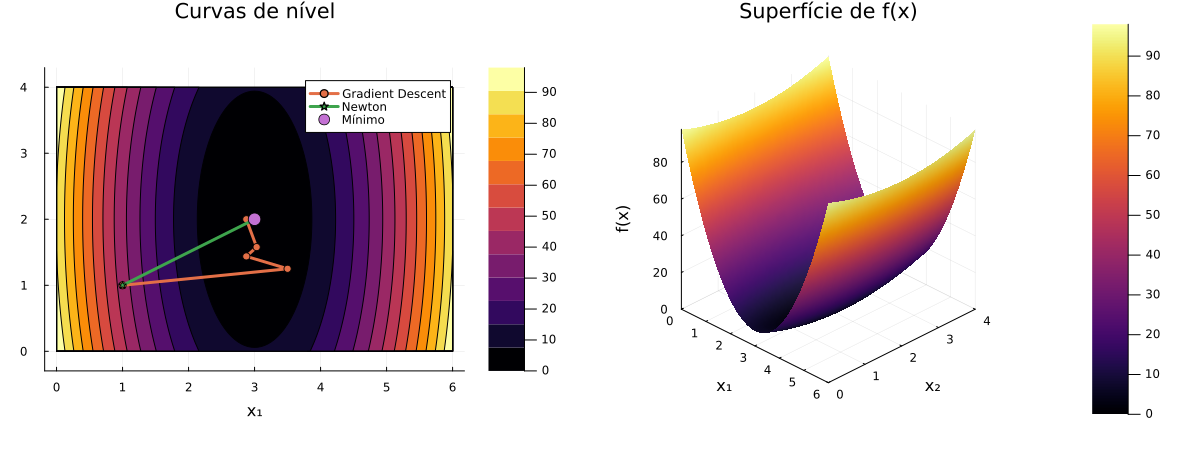

In [8]:
f2(x) = 10*(x[1] - 3)^2 + 2*(x[2] - 2)^2
x0_2 = [1.0, 1.0]

xmin_gd_2, xs_gd_2, fs_gd_2 = gradient_descent(f2, x0_2)
xmin_nt_2, xs_nt_2, fs_nt_2 = newton_method(f2, x0_2)

println("=== f(x) = 10(x₁-3)^2 + 2(x₂-2)^2 ===")
println("Gradient Descent -> xmin = ", xmin_gd_2, ", f(xmin) = ", f2(xmin_gd_2), ", iterações = ", length(xs_gd_2)-1)
println("Newton          -> xmin = ", xmin_nt_2, ", f(xmin) = ", f2(xmin_nt_2), ", iterações = ", length(xs_nt_2)-1)

x1v = 0.0:0.05:6.0
x2v = 0.0:0.05:4.0
Z2 = [f2([x1, x2]) for x2 in x2v, x1 in x1v]

gd_x1_2, gd_x2_2 = split_path(xs_gd_2)
nt_x1_2, nt_x2_2 = split_path(xs_nt_2)

p1 = contour(
    x1v, x2v, Z2;
    fill=true,
    aspect_ratio=:equal,
    levels=12,
    xlabel="x₁",
    ylabel="x₂",
    title="Curvas de nível"
)
plot!(p1, gd_x1_2, gd_x2_2, lw=3, marker=:circle, label="Gradient Descent")
plot!(p1, nt_x1_2, nt_x2_2, lw=3, marker=:star5, label="Newton")
scatter!(p1, [3.0], [2.0], markersize=7, label="Mínimo")

p2 = surface(
    x1v, x2v, Z2;
    xlabel="x₁",
    ylabel="x₂",
    zlabel="f(x)",
    title="Superfície de f(x)",
    camera=(45, 30)
)

plot(p1, p2, layout=(1,2), size=(1200,450))

Now implement the same methods for the function $f(x) = x_1^2 + x_2^2$. Use as start point $x_0 = [-2.0, 2.0]$

=== f(x) = x₁^2 + x₂^2 ===
Gradient Descent -> xmin = [0.0, 0.0], f(xmin) = 0.0, iterações = 1
Newton          -> xmin = [0.0, 0.0], f(xmin) = 0.0, iterações = 1


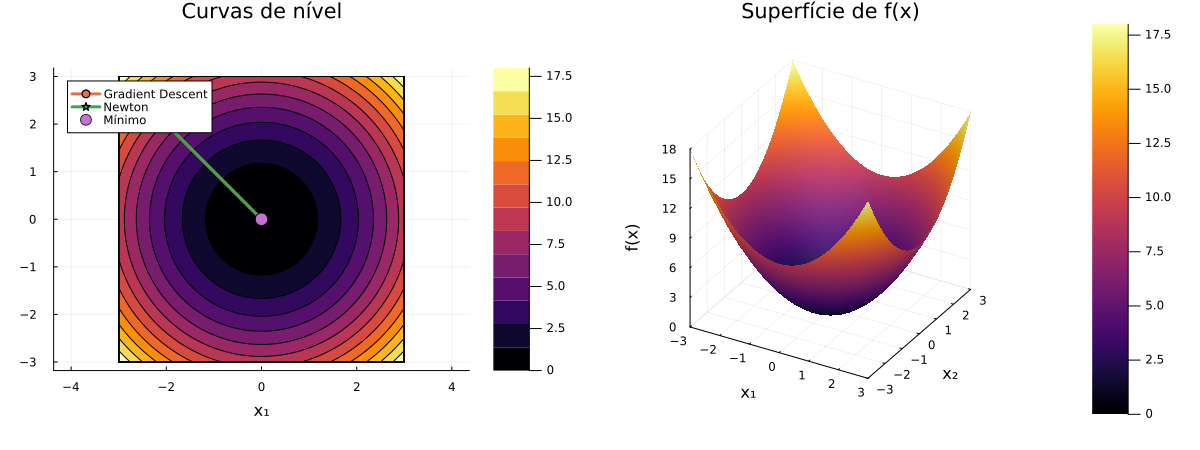

In [9]:
f3(x) = x[1]^2 + x[2]^2
x0_3 = [-2.0, 2.0]

xmin_gd_3, xs_gd_3, fs_gd_3 = gradient_descent(f3, x0_3)
xmin_nt_3, xs_nt_3, fs_nt_3 = newton_method(f3, x0_3)

println("=== f(x) = x₁^2 + x₂^2 ===")
println("Gradient Descent -> xmin = ", xmin_gd_3, ", f(xmin) = ", f3(xmin_gd_3), ", iterações = ", length(xs_gd_3)-1)
println("Newton          -> xmin = ", xmin_nt_3, ", f(xmin) = ", f3(xmin_nt_3), ", iterações = ", length(xs_nt_3)-1)

x1v = -3.0:0.05:3.0
x2v = -3.0:0.05:3.0
Z3 = [f3([x1, x2]) for x2 in x2v, x1 in x1v]

gd_x1_3, gd_x2_3 = split_path(xs_gd_3)
nt_x1_3, nt_x2_3 = split_path(xs_nt_3)

p3 = contour(
    x1v, x2v, Z3;
    fill=true,
    aspect_ratio=:equal,
    levels=12,
    xlabel="x₁",
    ylabel="x₂",
    title="Curvas de nível"
)
plot!(p3, gd_x1_3, gd_x2_3, lw=3, marker=:circle, label="Gradient Descent")
plot!(p3, nt_x1_3, nt_x2_3, lw=3, marker=:star5, label="Newton")
scatter!(p3, [0.0], [0.0], markersize=7, label="Mínimo")

p4 = surface(
    x1v, x2v, Z3;
    xlabel="x₁",
    ylabel="x₂",
    zlabel="f(x)",
    title="Superfície de f(x)"
)

plot(p3, p4, layout=(1,2), size=(1200,450))

Implement the same methods for the function $f(x) = x_1^2 + 100x_2^2$. Use as start point $x_0 = [-2.0, 2.0]$

=== f(x) = x₁^2 + 100x₂^2 ===
Ponto inicial = [-2.0, 2.0]
Gradient Descent -> xmin = [-0.022678888541844515, 0.00029491697350471726], f(xmin) = 0.0005230295876195246, iterações = 200
Newton          -> xmin = [0.0, 0.0], f(xmin) = 0.0, iterações = 1


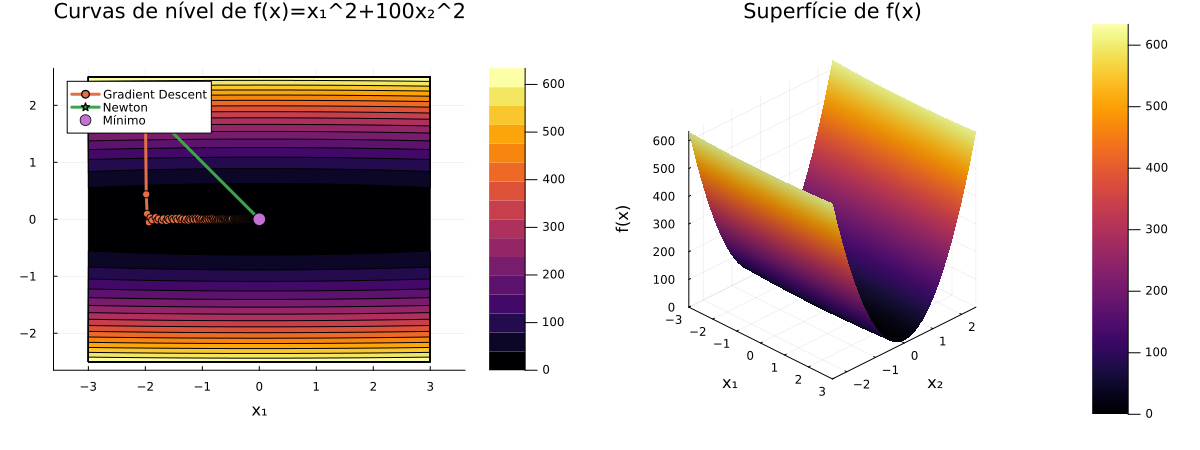

In [10]:
f4(x) = x[1]^2 + 100*x[2]^2
x0_4 = [-2.0, 2.0]

xmin_gd_4, xs_gd_4, fs_gd_4 = gradient_descent(f4, x0_4)
xmin_nt_4, xs_nt_4, fs_nt_4 = newton_method(f4, x0_4)

println("=== f(x) = x₁^2 + 100x₂^2 ===")
println("Ponto inicial = ", x0_4)
println("Gradient Descent -> xmin = ", xmin_gd_4, ", f(xmin) = ", f4(xmin_gd_4), ", iterações = ", length(xs_gd_4)-1)
println("Newton          -> xmin = ", xmin_nt_4, ", f(xmin) = ", f4(xmin_nt_4), ", iterações = ", length(xs_nt_4)-1)

x1v = -3.0:0.05:3.0
x2v = -2.5:0.05:2.5
Z4 = [f4([x1, x2]) for x2 in x2v, x1 in x1v]

gd_x1_4, gd_x2_4 = split_path(xs_gd_4)
nt_x1_4, nt_x2_4 = split_path(xs_nt_4)

p1 = contour(
    x1v, x2v, Z4;
    fill=true,
    aspect_ratio=:equal,
    levels=15,
    xlabel="x₁",
    ylabel="x₂",
    title="Curvas de nível de f(x)=x₁^2+100x₂^2"
)
plot!(p1, gd_x1_4, gd_x2_4, lw=3, marker=:circle, label="Gradient Descent")
plot!(p1, nt_x1_4, nt_x2_4, lw=3, marker=:star5, label="Newton")
scatter!(p1, [0.0], [0.0], markersize=7, label="Mínimo")

p2 = surface(
    x1v, x2v, Z4;
    xlabel="x₁",
    ylabel="x₂",
    zlabel="f(x)",
    title="Superfície de f(x)",
    camera=(45,30)
)

plot(p1, p2, layout=(1,2), size=(1200,450))

For the last problem, perform the change of variables: $x_2 = \frac{1}{10}y_2$

In [11]:
# =========================================================
# Change of variables for the last problem (f4): x2 = (1/10) y2
#   F(x1, y2) = f4(x1, x2 = y2/10) = x1^2 + 100*(y2/10)^2
#              = x1^2 + y2^2
#
# Essa mudança transforma f4 (mal condicionada) em uma função
# perfeitamente condicionada (número de condição = 1).
# Como resultado, o Gradient Descent converge bem mais rápido.
# =========================================================

# função nas novas variáveis
F4(v) = v[1]^2 + v[2]^2        # x1^2 + y2^2

# ponto inicial equivalente: x0_4 = [-2, 2] => (x1, y2) = (-2, 20)
v0_4 = [-2.0, 20.0]

xmin_gd_4y, xs_gd_4y, fs_gd_4y = gradient_descent(F4, v0_4)
xmin_nt_4y, xs_nt_4y, fs_nt_4y = newton_method(F4, v0_4)

# Convertendo o resultado de volta para (x1, x2)
x1_star, y2_star = xmin_gd_4y
x2_star = y2_star / 10

println("=== f4 com mudança de variáveis x2 = y2/10 ===")
println("Em (x1, y2):")
println("Gradient Descent -> v = ", xmin_gd_4y,
        ", iterações = ", length(xs_gd_4y)-1)
println("Newton           -> v = ", xmin_nt_4y,
        ", iterações = ", length(xs_nt_4y)-1)
println("Em (x1, x2):")
println("  x1* = ", x1_star, ",  x2* = y2*/10 = ", x2_star)
println()
println("Compare: no original o GD precisou de muitas mais iterações.")


=== f4 com mudança de variáveis x2 = y2/10 ===
Em (x1, y2):
Gradient Descent -> v = [0.0, 0.0], iterações = 1
Newton           -> v = [0.0, 0.0], iterações = 1
Em (x1, x2):
  x1* = 0.0,  x2* = y2*/10 = 0.0

Compare: no original o GD precisou de muitas mais iterações.


##  Gradient Descent with Backtracking Line Search:

Given function:
\begin{align*}
    f(x_1, x_2, x_3) = x_{3} \log \Big( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}} \Big) + (x_{3}-2)^2 + e^{\frac{1}{x_{1} + x_{2}}}
\end{align*}

$ \textbf{dom} \; f: \{ \mathbf{x} \in \mathbb{R}^3 : x_1 +x _2 >0, x_3 > 0 \}  $

Define the function in the cell below:

In [12]:
# ============================================================
# Gradient Descent com Backtracking Line Search
# f(x1,x2,x3) = x3*log(exp(x1/x3) + exp(x2/x3)) + (x3-2)^2 + exp(1/(x1+x2))
# dom f: x1 + x2 > 0, x3 > 0
# Mudança de variáveis: x2 = (1/10) * y2  =>  variáveis (x1, y2, x3)
# ============================================================

using LinearAlgebra
using Printf

# ---------- Função original f(x1, x2, x3) ----------
# Usamos log-sum-exp estável para evitar overflow em exp(x/x3)
function f_original(x1, x2, x3)
    a = x1 / x3
    b = x2 / x3
    m = max(a, b)
    lse = m + log(exp(a - m) + exp(b - m))   # log(e^a + e^b) estável
    return x3 * lse + (x3 - 2)^2 + exp(1 / (x1 + x2))
end

# ---------- Gradiente analítico de f(x1, x2, x3) ----------
# Seja s = e^(x1/x3) + e^(x2/x3),  p1 = e^(x1/x3)/s,  p2 = e^(x2/x3)/s
# df/dx1 = p1 - e^(1/(x1+x2)) / (x1+x2)^2
# df/dx2 = p2 - e^(1/(x1+x2)) / (x1+x2)^2
# df/dx3 = log(s) - (p1*x1 + p2*x2)/x3 + 2(x3 - 2)
function grad_original(x1, x2, x3)
    a = x1 / x3
    b = x2 / x3
    m = max(a, b)
    ea = exp(a - m);  eb = exp(b - m)
    s_shift = ea + eb
    p1 = ea / s_shift
    p2 = eb / s_shift
    log_s = m + log(s_shift)

    t = x1 + x2
    e_inv = exp(1 / t)
    common = e_inv / t^2

    g1 = p1 - common
    g2 = p2 - common
    g3 = log_s - (p1 * x1 + p2 * x2) / x3 + 2 * (x3 - 2)
    return [g1, g2, g3]
end

# ---------- Aplicando mudança de variáveis: x2 = y2/10 ----------
# F(x1, y2, x3) = f(x1, y2/10, x3)
# ∇F = [ df/dx1 ,  (1/10) * df/dx2 ,  df/dx3 ]
function F(v)
    x1, y2, x3 = v
    return f_original(x1, y2 / 10, x3)
end

function gradF(v)
    x1, y2, x3 = v
    g = grad_original(x1, y2 / 10, x3)
    return [g[1], g[2] / 10, g[3]]
end

# ---------- Verifica se o ponto está no domínio ----------
function in_domain(v)
    x1, y2, x3 = v
    x2 = y2 / 10
    return (x1 + x2 > 0) && (x3 > 0)
end

# ---------- Backtracking Line Search (Armijo) ----------
# Parâmetros clássicos de Boyd & Vandenberghe: α ∈ (0, 0.5), β ∈ (0, 1)
function backtracking(F, v, grad, dir; α = 0.25, β = 0.5, t0 = 1.0)
    t = t0
    fv = F(v)
    gd = dot(grad, dir)       # derivada direcional (deve ser < 0)

    # 1) Garantir que v + t*dir permaneça no domínio
    while !in_domain(v .+ t .* dir)
        t *= β
        if t < 1e-20
            return t
        end
    end

    # 2) Condição de Armijo
    while F(v .+ t .* dir) > fv + α * t * gd
        t *= β
        if t < 1e-20
            break
        end
    end
    return t
end

# ---------- Gradient Descent ----------
function gradient_descent(F, gradF, v0;
                          tol = 1e-6, maxiter = 1000,
                          α = 0.25, β = 0.5, verbose = true)
    v = copy(v0)
    history = Float64[]

    if verbose
        @printf("%-6s %-14s %-14s %-14s\n", "iter", "f(v)", "||grad||", "step t")
        println("-"^55)
    end

    for k in 1:maxiter
        g = gradF(v)
        ng = norm(g)
        push!(history, F(v))

        if verbose && (k == 1 || k % 10 == 0)
            @printf("%-6d %-14.6e %-14.6e\n", k, F(v), ng)
        end

        if ng < tol
            if verbose
                println("Convergência atingida em $k iterações.")
            end
            return v, history, k
        end

        dir = -g
        t = backtracking(F, v, g, dir; α = α, β = β)
        v = v .+ t .* dir
    end
    if verbose
        println("Número máximo de iterações atingido.")
    end
    return v, history, maxiter
end

# ============================================================
# Execução
# ============================================================

# Ponto inicial viável: x1 + x2 > 0 e x3 > 0
# Nas variáveis (x1, y2, x3): x1 + y2/10 > 0, x3 > 0
v0 = [1.0, 1.0, 1.0]

println("Ponto inicial (x1, y2, x3) = ", v0)
println("Equivalente (x1, x2, x3)   = ", [v0[1], v0[2]/10, v0[3]])
println("F(v0) = ", F(v0))
println()

v_opt, hist, iters = gradient_descent(F, gradF, v0;
                                      tol = 1e-8, maxiter = 2000,
                                      α = 0.25, β = 0.5)

println()
println("=============== RESULTADO ===============")
@printf("Iterações        : %d\n", iters)
@printf("x1*              : %.8f\n", v_opt[1])
@printf("y2*              : %.8f   (=> x2* = %.8f)\n", v_opt[2], v_opt[2]/10)
@printf("x3*              : %.8f\n", v_opt[3])
@printf("f(x*)            : %.10f\n", F(v_opt))
@printf("||grad f(x*)||   : %.3e\n", norm(gradF(v_opt)))
println("=========================================")

Ponto inicial (x1, y2, x3) = [1.0, 1.0, 1.0]
Equivalente (x1, x2, x3)   = [1.0, 0.1, 1.0]
F(v0) = 4.8232189593551

iter   f(v)           ||grad||       step t        
-------------------------------------------------------
1      4.823219e+00   1.945235e+00  
10     4.061734e+00   5.695090e-02  
20     4.048127e+00   3.668571e-02  
30     4.035412e+00   3.612314e-02  
40     4.023845e+00   3.879156e-02  
50     4.013489e+00   5.050550e-02  
60     4.003884e+00   3.053787e-02  
70     3.995006e+00   2.932873e-02  
80     3.986926e+00   2.850021e-02  
90     3.979585e+00   2.850553e-02  
100    3.972934e+00   3.015091e-02  
110    3.966938e+00   3.449468e-02  
120    3.961581e+00   4.246145e-02  
130    3.956496e+00   2.188621e-02  
140    3.951928e+00   2.086102e-02  
150    3.947786e+00   1.989320e-02  
160    3.944031e+00   1.898730e-02  
170    3.940628e+00   1.814942e-02  
180    3.937545e+00   1.738709e-02  
190    3.934753e+00   1.670888e-02  
200    3.932225e+00   1.612364e-02  


Defining the first derivative: 

$\nabla f = [ \partial f/\partial x_1 \; \partial f/\partial x_2 \; \partial f/\partial x_3]^T   $

$$ \implies \nabla f = \begin{Bmatrix}
\frac{e^{\frac{x_{1}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2}  \\ \\
\frac{e^{\frac{x_{2}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2} \\ \\
 log(e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) - \frac{x_1 e^{\frac{x_{1}} {x_{3}}} + x_2 e^{\frac{x_{2}} {x_{3}}}}{x_3 ( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) } + 2(x_3-2)
\end{Bmatrix}$$

#### implement the first derivative 

In [13]:
# ============================================================
# Implementação da primeira derivada (gradiente) com ajustes
#
# f(x1, x2, x3) = x3 * log(exp(x1/x3) + exp(x2/x3))
#                 + (x3 - 2)^2
#                 + exp(1 / (x1 + x2))
#
# dom f: { x ∈ R^3 : x1 + x2 > 0, x3 > 0 }
# ============================================================

using LinearAlgebra
using Printf

# ---------- Função objetivo com verificação de domínio ----------
function f(x::AbstractVector)
    x1, x2, x3 = x

    if x1 + x2 <= 0 || x3 <= 0
        throw(DomainError(x, "É preciso ter x1 + x2 > 0 e x3 > 0."))
    end

    a = x1 / x3
    b = x2 / x3
    m = max(a, b)                                  # log-sum-exp estável
    lse = m + log(exp(a - m) + exp(b - m))         # = log(e^(x1/x3) + e^(x2/x3))

    return x3 * lse + (x3 - 2)^2 + exp(1 / (x1 + x2))
end

# ---------- Gradiente analítico com verificação de domínio ----------
function grad_f(x::AbstractVector)
    x1, x2, x3 = x

    if x1 + x2 <= 0 || x3 <= 0
        throw(DomainError(x, "É preciso ter x1 + x2 > 0 e x3 > 0."))
    end

    # --- exponenciais em forma numericamente estável ---
    a = x1 / x3
    b = x2 / x3
    m = max(a, b)

    ea = exp(a - m)           # proporcional a e^(x1/x3)
    eb = exp(b - m)           # proporcional a e^(x2/x3)
    S  = ea + eb

    # --- razões softmax ---
    p1 = ea / S
    p2 = eb / S

    # --- log-soma estável ---
    log_sum = m + log(S)

    # --- termo exp(1 / (x1 + x2)) ---
    t = x1 + x2
    eC = exp(1 / t)
    termC = eC / (t^2)

    # --- componentes do gradiente ---
    df_dx1 = p1 - termC
    df_dx2 = p2 - termC
    df_dx3 = log_sum - (x1 * p1 + x2 * p2) / x3 + 2 * (x3 - 2)

    return [df_dx1, df_dx2, df_dx3]
end

# ============================================================
# Gradiente numérico por diferenças finitas centradas
# ============================================================
function grad_numerico(f, x; h = 1e-6)
    n = length(x)
    g = zeros(n)

    for i in 1:n
        e = zeros(n)
        e[i] = h
        g[i] = (f(x .+ e) - f(x .- e)) / (2 * h)
    end

    return g
end

# ============================================================
# Teste: comparação entre gradiente analítico e numérico
# ============================================================
println("============ Verificação do gradiente ============\n")

pontos_teste = [
    [1.0, 1.0, 1.0],
    [0.5, 2.0, 1.5],
    [2.0, 3.0, 0.8],
    [0.3, 0.4, 2.5],
]

for (k, x) in enumerate(pontos_teste)
    g_ana = grad_f(x)
    g_num = grad_numerico(f, x)
    err   = norm(g_ana - g_num)

    println("Ponto $k: x = $x")
    @printf("  f(x)         = %.8f\n", f(x))
    @printf("  ∇f analítico = [% .8f, % .8f, % .8f]\n", g_ana[1], g_ana[2], g_ana[3])
    @printf("  ∇f numérico  = [% .8f, % .8f, % .8f]\n", g_num[1], g_num[2], g_num[3])
    @printf("  ‖erro‖       = %.3e\n\n", err)
end

============ Verificação do gradiente ============

Ponto 1: x = [1.0, 1.0, 1.0]
  f(x)         = 4.34186845
  ∇f analítico = [ 0.08781968,  0.08781968, -1.30685282]
  ∇f numérico  = [ 0.08781968,  0.08781968, -1.30685282]
  ‖erro‖       = 5.325e-10

Ponto 2: x = [0.5, 2.0, 1.5]
  f(x)         = 4.21171723
  ∇f analítico = [ 0.03024947,  0.49236663, -0.41779689]
  ∇f numérico  = [ 0.03024947,  0.49236663, -0.41779689]
  ‖erro‖       = 2.466e-10

Ponto 3: x = [2.0, 3.0, 0.8]
  f(x)         = 5.86294602
  ∇f analítico = [ 0.17384403,  0.72844375, -1.86969575]
  ∇f numérico  = [ 0.17384403,  0.72844375, -1.86969574]
  ‖erro‖       = 1.113e-09

Ponto 4: x = [0.3, 0.4, 2.5]
  f(x)         = 6.50610180
  ∇f analítico = [-8.02578210, -8.00578477,  1.69294722]
  ∇f numérico  = [-8.02578210, -8.00578477,  1.69294722]
  ‖erro‖       = 1.958e-10



In [14]:
using LinearAlgebra
using Printf

# ============================================================
# Função objetivo
# ============================================================
function f(x::AbstractVector)
    x1, x2, x3 = x

    if x1 + x2 <= 0 || x3 <= 0
        throw(DomainError(x, "É preciso ter x1 + x2 > 0 e x3 > 0."))
    end

    a = x1 / x3
    b = x2 / x3
    m = max(a, b)
    lse = m + log(exp(a - m) + exp(b - m))

    return x3 * lse + (x3 - 2)^2 + exp(1 / (x1 + x2))
end

# ============================================================
# Gradiente analítico
# ============================================================
function grad_f(x::AbstractVector)
    x1, x2, x3 = x

    if x1 + x2 <= 0 || x3 <= 0
        throw(DomainError(x, "É preciso ter x1 + x2 > 0 e x3 > 0."))
    end

    a = x1 / x3
    b = x2 / x3
    m = max(a, b)

    ea = exp(a - m)
    eb = exp(b - m)
    S  = ea + eb

    p1 = ea / S
    p2 = eb / S
    log_sum = m + log(S)

    t = x1 + x2
    eC = exp(1 / t)
    termC = eC / (t^2)

    df_dx1 = p1 - termC
    df_dx2 = p2 - termC
    df_dx3 = log_sum - (x1 * p1 + x2 * p2) / x3 + 2 * (x3 - 2)

    return [df_dx1, df_dx2, df_dx3]
end

# ============================================================
# Parâmetros do backtracking
# ============================================================
α = 0.4
β = 0.5
ϵ = 1e-5

# ponto inicial
x0 = [3.0, 4.0, 5.0]

# ============================================================
# Backtracking line search
# ============================================================
function backtracking_line_search(f, grad_f, x, d; α=0.4, β=0.5, t0=1.0)
    t = t0
    fx = f(x)
    gx = grad_f(x)

    while true
        x_new = x .+ t .* d

        if x_new[1] + x_new[2] > 0 && x_new[3] > 0 &&
           f(x_new) <= fx + α * t * dot(gx, d)
            return t
        end

        t *= β
    end
end

# ============================================================
# Gradient Descent with Backtracking
# ============================================================
function gradient_descent_backtracking(f, grad_f, x0; α=0.4, β=0.5, ϵ=1e-5, maxiter=10_000)
    x = copy(x0)

    xs = [copy(x)]
    fs = [f(x)]
    ts = Float64[]

    for k in 1:maxiter
        g = grad_f(x)

        if norm(g) <= ϵ
            println("Convergiu em $(k-1) iterações.")
            return x, xs, fs, ts
        end

        d = -g
        t = backtracking_line_search(f, grad_f, x, d; α=α, β=β)

        x = x .+ t .* d

        push!(xs, copy(x))
        push!(fs, f(x))
        push!(ts, t)
    end

    println("Atingiu o número máximo de iterações.")
    return x, xs, fs, ts
end

# ============================================================
# Execução
# ============================================================
xmin, xs, fs, ts = gradient_descent_backtracking(f, grad_f, x0; α=α, β=β, ϵ=ϵ)

println("\nResultado final:")
println("xmin = ", xmin)
@printf("f(xmin) = %.10f\n", f(xmin))
@printf("‖∇f(xmin)‖ = %.6e\n", norm(grad_f(xmin)))
println("iterações = ", length(xs) - 1)

Convergiu em 30 iterações.

Resultado final:
xmin = [0.9261872701983407, 0.9262296480441214, 1.6534264097600673]
f(xmin) = 3.9081137864
‖∇f(xmin)‖ = 9.061686e-06
iterações = 30


In [15]:
x0 = [3.0, 4.0, 5.0]

3-element Vector{Float64}:
 3.0
 4.0
 5.0

Defining parameters for backtracking search: $\alpha = 0,4; \beta = 0,5;$ tolerance (eps) $= 10^{-5}$

In [16]:
# Célula 1 — parameters for backtracking
α = 0.4
β = 0.5
ϵ = 1e-5

1.0e-5

Start Point: [3.0, 4.0, 5.0]

In [17]:
# Célula 2 — start point
x0 = [3.0, 4.0, 5.0]

3-element Vector{Float64}:
 3.0
 4.0
 5.0

Ensuring domain:

$ \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t $ \
where, $\Delta x = -\nabla f(x)$

In [18]:
# ============================================================
# Ensuring domain:
# While x + tΔx ∉ dom f, set t := βt
# where Δx = -∇f(x)
# ============================================================

using LinearAlgebra
using Printf

# domínio de f
function in_domain(x::AbstractVector)
    return (x[1] + x[2] > 0) && (x[3] > 0)
end

# ponto atual
x = copy(x0)

# direção de descida
Δx = -grad_f(x)

# passo inicial
t = 1.0

# garante que x + tΔx permaneça no domínio
while !in_domain(x .+ t .* Δx)
    t *= β
end

x_domain = x .+ t .* Δx

println("========== Ensuring domain ==========")
println("x = ", x)
println("Δx = ", Δx)
@printf("t = %.10f\n", t)
println("x + tΔx = ", x_domain)
println("Está no domínio? ", in_domain(x_domain))

========== Ensuring domain ==========
x = [3.0, 4.0, 5.0]
Δx = [-0.4266238599345607, -0.5262918545595165, -6.688172069919096]
t = 0.5000000000
x + tΔx = [2.7866880700327195, 3.7368540727202415, 1.655913965040452]
Está no domínio? true


Backtracking algorithm:

$
\text{Given a descent direction } \Delta x = -\nabla f(x) \text{ for } f \text{ at } x \in \textbf{dom} f, \alpha \in (0, 0.5), \beta \in (0, 1).$

\begin{array}{l}
\text{Set } t := 1. \\ 
\text{Ensure domain:} \; \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t \\
\text{While } f(x + t\Delta x) > f(x) + \alpha t \nabla f(x)^T \Delta x, \text{ set } t := \beta t.
\end{array}


In [19]:
# ============================================================
# Backtracking algorithm (versão corrigida)
# Dado x ∈ dom f, usa a direção de descida Δx = -∇f(x)
# e encontra um passo t > 0 satisfazendo:
#   1) x + tΔx ∈ dom f
#   2) f(x + tΔx) ≤ f(x) + α t ∇f(x)ᵀ Δx         (Armijo)
# ============================================================

using LinearAlgebra
using Printf

# domínio da função: x1 + x2 > 0 e x3 > 0
function in_domain(x::AbstractVector)
    return (x[1] + x[2] > 0) && (x[3] > 0)
end

# backtracking line search
function backtracking(f, grad_f, x; α = 0.4, β = 0.5,
                      t_min = 1e-20, maxiter = 200)
    # validação dos parâmetros
    if !(0 < α < 0.5)
        error("É preciso ter 0 < α < 0.5")
    end
    if !(0 < β < 1)
        error("É preciso ter 0 < β < 1")
    end
    if !in_domain(x)
        error("O ponto x não pertence ao domínio de f")
    end

    Δx  = -grad_f(x)            # direção de descida
    fx  = f(x)
    gx  = grad_f(x)
    gd  = dot(gx, Δx)           # = -‖∇f(x)‖² (deve ser < 0)

    # Se gd ≥ 0, Δx não é direção de descida — nada a fazer.
    if gd ≥ 0
        @warn "Δx não é direção de descida (∇fᵀΔx ≥ 0)."
        return 0.0, Δx, copy(x)
    end

    t = 1.0
    iter = 0

    # Laço único: a CADA tentativa, primeiro garante domínio,
    # só depois testa Armijo. Assim nunca avaliamos f fora de dom f.
    while true
        iter += 1
        if iter > maxiter || t < t_min
            @warn "Backtracking atingiu limite (t = $t)."
            break
        end

        # 1) garantir domínio
        if !in_domain(x .+ t .* Δx)
            t *= β
            continue
        end

        # 2) testar Armijo
        if f(x .+ t .* Δx) ≤ fx + α * t * gd
            break                     # passo aceito
        else
            t *= β
        end
    end

    return t, Δx, x .+ t .* Δx
end

# ============================================================
# Função de teste: f(x1,x2,x3) = x3*log(e^{x1/x3}+e^{x2/x3})
#                                + (x3-2)^2 + e^{1/(x1+x2)}
# ============================================================
function f_test(x::AbstractVector)
    x1, x2, x3 = x
    a, b = x1 / x3, x2 / x3
    m = max(a, b)
    lse = m + log(exp(a - m) + exp(b - m))
    return x3 * lse + (x3 - 2)^2 + exp(1 / (x1 + x2))
end

function grad_f_test(x::AbstractVector)
    x1, x2, x3 = x
    a, b = x1 / x3, x2 / x3
    m = max(a, b)
    ea, eb = exp(a - m), exp(b - m)
    S = ea + eb
    p1, p2 = ea / S, eb / S
    t = x1 + x2
    termC = exp(1 / t) / t^2
    return [ p1 - termC,
             p2 - termC,
             m + log(S) - (x1 * p1 + x2 * p2) / x3 + 2 * (x3 - 2) ]
end

# ------------------------------------------------------------
# Exemplo de uso no ponto inicial x0
# ------------------------------------------------------------
x0 = [3.0, 4.0, 5.0]
α  = 0.4
β  = 0.5

t, Δx, x_new = backtracking(f_test, grad_f_test, x0; α = α, β = β)

println("============ Backtracking ============")
println("x         = ", x0)
println("Δx = -∇f(x) = ", Δx)
@printf("t         = %.10f\n", t)
println("x_new = x + tΔx = ", x_new)
@printf("f(x)     = %.10f\n", f_test(x0))
@printf("f(x_new) = %.10f\n", f_test(x_new))
@printf("Redução: f(x) - f(x_new) = %.6f\n", f_test(x0) - f_test(x_new))

============ Backtracking ============
x         = [3.0, 4.0, 5.0]
Δx = -∇f(x) = [-0.4266238599345607, -0.5262918545595165, -6.688172069919096]
t         = 0.5000000000
x_new = x + tΔx = [2.7866880700327195, 3.7368540727202415, 1.655913965040452]
f(x)     = 17.1442593418
f(x_new) = 5.7608583753
Redução: f(x) - f(x_new) = 11.383401


### Algorithm: Gradient Descent

1. **Input:** Starting point $x$ in $\text{dom} \, f$

2. **Repeat until stopping criterion is satisfied:**

    a. $\Delta x := -\nabla f(x)$
    
    b. **Line search:** Choose step size $t$ via backtracking line search
    
    c. **Update:** $x := x + t \Delta x$

In [20]:
# ============================================================
# Algorithm: Gradient Descent with Backtracking Line Search
# Usa: f, grad_f, α, β, ϵ, x0
# ============================================================

using LinearAlgebra
using Printf

function gradient_descent_backtracking(f, grad_f, x0; α=0.4, β=0.5, ϵ=1e-5, maxiter=10_000)
    x = copy(x0)

    xs = [copy(x)]        # histórico dos pontos
    fs = [f(x)]           # histórico dos valores da função
    ts = Float64[]        # histórico dos passos

    for k in 1:maxiter
        g = grad_f(x)

        # critério de parada
        if norm(g) <= ϵ
            return x, xs, fs, ts, k - 1
        end

        # direção de descida
        Δx = -g

        # backtracking line search
        t = 1.0
        fx = f(x)

        while true
            x_trial = x .+ t .* Δx

            # garantir que o novo ponto continue no domínio
            if x_trial[1] + x_trial[2] > 0 &&
               x_trial[3] > 0 &&
               f(x_trial) <= fx + α * t * dot(g, Δx)
                break
            end

            t *= β
        end

        # atualização
        x = x .+ t .* Δx

        push!(xs, copy(x))
        push!(fs, f(x))
        push!(ts, t)
    end

    return x, xs, fs, ts, maxiter
end

# ------------------------------------------------------------
# Execução
# ------------------------------------------------------------
xmin, xs, fs, ts, iters = gradient_descent_backtracking(
    f, grad_f, x0;
    α=α, β=β, ϵ=ϵ
)

println("========== Gradient Descent with Backtracking ==========")
println("Ponto inicial x0 = ", x0)
println("Solução aproximada xmin = ", xmin)
@printf("f(xmin) = %.10f\n", f(xmin))
@printf("‖∇f(xmin)‖ = %.6e\n", norm(grad_f(xmin)))
println("Número de iterações = ", iters)

println("\nÚltimos step sizes:")
println(ts[max(1, end-4):end])

========== Gradient Descent with Backtracking ==========
Ponto inicial x0 = [3.0, 4.0, 5.0]
Solução aproximada xmin = [0.9261872701983407, 0.9262296480441214, 1.6534264097600673]
f(xmin) = 3.9081137864
‖∇f(xmin)‖ = 9.061686e-06
Número de iterações = 30

Últimos step sizes:
[1.0, 0.5, 1.0, 1.0, 1.0]


## Optimisation using Newton's Method:

Given function:
\begin{align*}
    f(x_1, x_2, x_3) = x_{3} \log \Big( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}} \Big) + (x_{3}-2)^2 + e^{\frac{1}{x_{1} + x_{2}}}
\end{align*}

$ \textbf{dom} \; f: \{ \mathbf{x} \in \mathbb{R}^3 : x_1 +x _2 >0, x_3 > 0 \}  $

Defining the first derivative: 

$\nabla f = [ \partial f/\partial x_1 \; \partial f/\partial x_2 \; \partial f/\partial x_3]^T   $

$$ \implies \nabla f = \begin{Bmatrix}
\frac{e^{\frac{x_{1}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2}  \\ \\
\frac{e^{\frac{x_{2}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2} \\ \\
 log(e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) - \frac{x_1 e^{\frac{x_{1}} {x_{3}}} + x_2 e^{\frac{x_{2}} {x_{3}}}}{x_3 ( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) } + 2(x_3-2)
\end{Bmatrix}$$

Defining the Second Derivative:

The gradient vector, denoted as $\nabla f$, is the vector of partial derivatives:
$
\nabla f(x) = \left(\frac{\partial f}{\partial x_1}, \frac{\partial f}{\partial x_2}, \ldots, \frac{\partial f}{\partial x_n}\right)
$

The finite difference approximation for the gradient at a point $x$ is given by:
$
\nabla_f(x) \approx \frac{f(x + h\mathbf{i}) - f(x)}{h}
$
where $\mathbf{i}$ is a unit vector along one of the coordinate axes.

The second derivative matrix is then approximated as:
$
\nabla^2 f(x) \approx \frac{1}{h} \left(\nabla_f(x + h\mathbf{i}) - \nabla_f(x)\right)
$

The reshaped second derivative matrix is a $3 \times 3$ matrix obtained from the flattened vector.

In [21]:
# ============================================================
# Optimisation using Newton's Method
# Função, gradiente e parâmetros α, β, ϵ, x0
# já devem ter sido definidos antes no notebook.
# ============================================================

using LinearAlgebra
using Printf

# ---------------- domínio ----------------
function in_domain(x::AbstractVector)
    return (x[1] + x[2] > 0) && (x[3] > 0)
end

# ---------------- Hessiana por diferenças finitas ----------------
# ∇²f(x)[:,j] ≈ (∇f(x + h e_j) - ∇f(x)) / h
function hessian_fd(grad_f, x; h=1e-6)
    n = length(x)
    H = zeros(n, n)
    gx = grad_f(x)

    for j in 1:n
        e = zeros(n)
        e[j] = h
        H[:, j] = (grad_f(x .+ e) - gx) / h
    end

    return 0.5 * (H + H')   # simetrização numérica
end

# ---------------- Backtracking para Newton ----------------
function backtracking_newton(f, grad_f, x, Δx; α=0.4, β=0.5)
    t = 1.0
    fx = f(x)
    gx = grad_f(x)

    # garantir domínio
    while !in_domain(x .+ t .* Δx)
        t *= β
    end

    # condição de Armijo
    while f(x .+ t .* Δx) > fx + α * t * dot(gx, Δx)
        t *= β
        while !in_domain(x .+ t .* Δx)
            t *= β
        end
    end

    return t
end

# ---------------- Newton's Method with Backtracking ----------------
function newton_method_backtracking(f, grad_f, x0; α=0.4, β=0.5, ϵ=1e-5, maxiter=200, h=1e-6)
    x = copy(x0)

    xs = [copy(x)]
    fs = [f(x)]
    ts = Float64[]

    for k in 1:maxiter
        g = grad_f(x)

        if norm(g) <= ϵ
            return x, xs, fs, ts, k - 1
        end

        H = hessian_fd(grad_f, x; h=h)
        Δx = -(H \ g)
        t = backtracking_newton(f, grad_f, x, Δx; α=α, β=β)

        x = x .+ t .* Δx

        push!(xs, copy(x))
        push!(fs, f(x))
        push!(ts, t)
    end

    return x, xs, fs, ts, maxiter
end

# ---------------- execução ----------------
xmin_nt, xs_nt, fs_nt, ts_nt, iters_nt = newton_method_backtracking(
    f, grad_f, x0;
    α=α, β=β, ϵ=ϵ
)

println("========== Newton with Backtracking ==========")
println("x0 = ", x0)
println("xmin = ", xmin_nt)
@printf("f(xmin) = %.10f\n", f(xmin_nt))
@printf("‖∇f(xmin)‖ = %.6e\n", norm(grad_f(xmin_nt)))
println("iterações = ", iters_nt)
println("step sizes = ", ts_nt)

========== Newton with Backtracking ==========
x0 = [3.0, 4.0, 5.0]
xmin = [0.926208363676319, 0.926208365485533, 1.6534264097118465]
f(xmin) = 3.9081137863
‖∇f(xmin)‖ = 1.833178e-07
iterações = 5
step sizes = [0.0625, 0.5, 1.0, 1.0, 1.0]


Defining parameters for backtracking search and the start point: $\alpha = 0,4; \beta = 0,5;$ tolerance (eps) $= 10^{-5}$; Start Point: [3.0, 4.0, 5.0]

In [22]:
# Defining parameters for backtracking search and the start point
α = 0.4
β = 0.5
ϵ = 1e-5
x0 = [3.0, 4.0, 5.0]

3-element Vector{Float64}:
 3.0
 4.0
 5.0

Ensuring domain:

$ \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t $ \
where
$\Delta x = -\nabla^2 f(x)^{-1} \nabla f(x)$

In [23]:
# ============================================================
# Ensuring domain for Newton's Method
# While x + tΔx ∉ dom f, set t := βt
# where Δx = -∇²f(x)^(-1) ∇f(x)
# ============================================================

using LinearAlgebra
using Printf

# domínio
function in_domain(x::AbstractVector)
    return (x[1] + x[2] > 0) && (x[3] > 0)
end

# Hessiana aproximada por diferenças finitas do gradiente
function hessian_fd(grad_f, x; h=1e-6)
    n = length(x)
    H = zeros(n, n)
    gradx0 = grad_f(x)

    for j in 1:n
        e = zeros(n)
        e[j] = h
        H[:, j] = (grad_f(x .+ e) - gradx0) / h
    end

    return 0.5 * (H + H')   # simetrização numérica
end

# ponto atual
x = copy(x0)

# gradiente e Hessiana
gradx = grad_f(x)
H = hessian_fd(grad_f, x)

# direção de Newton
Δx = -(H \ gradx)

# passo inicial
t = 1.0

# garantindo domínio
while !in_domain(x .+ t .* Δx)
    t *= β
end

x_domain = x .+ t .* Δx

println("========== Ensuring domain (Newton) ==========")
println("x = ", x)
println("∇f(x) = ", gradx)
println("Δx = ", Δx)
@printf("t = %.10f\n", t)
println("x + tΔx = ", x_domain)
println("Está no domínio? ", in_domain(x_domain))

========== Ensuring domain (Newton) ==========
x = [3.0, 4.0, 5.0]
∇f(x) = [0.4266238599345607, 0.5262918545595165, 6.688172069919096]
Δx = [-32.21799174494706, -33.894485948957225, -3.3490695157238557]
t = 0.0625000000
x + tΔx = [0.986375515940809, 1.8815946281901734, 4.790683155267259]
Está no domínio? true


Backtracking algorithm:

$
\text{Given a descent direction } \Delta x = -\nabla^2 f(x)^{-1} \nabla f(x) \text{ for } f \text{ at } x \in \textbf{dom} f, \alpha \in (0, 0.5), \beta \in (0, 1).$

\begin{array}{l}
\text{Set } t := 1. \\ 
\text{Ensure domain:} \; \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t \\
\text{While } f(x + t\Delta x) > f(x) + \alpha t \nabla f(x)^T \Delta x, \text{ set } t := \beta t.
\end{array}


In [24]:
# ============================================================
# Backtracking algorithm for Newton's Method
# Given Δx = -∇²f(x)^(-1) ∇f(x)
# Set t := 1
# Ensure domain: while x + tΔx ∉ dom f, set t := βt
# While f(x + tΔx) > f(x) + α t ∇f(x)'Δx, set t := βt
# ============================================================

using LinearAlgebra
using Printf

# domínio
function in_domain(x::AbstractVector)
    return (x[1] + x[2] > 0) && (x[3] > 0)
end

# Hessiana aproximada por diferenças finitas do gradiente
function hessian_fd(grad_f, x; h=1e-6)
    n = length(x)
    H = zeros(n, n)
    gradx0 = grad_f(x)

    for j in 1:n
        e = zeros(n)
        e[j] = h
        H[:, j] = (grad_f(x .+ e) - gradx0) / h
    end

    return 0.5 * (H + H')   # simetrização numérica
end

# ponto atual
x = copy(x0)

# gradiente, Hessiana e direção de Newton
gradx = grad_f(x)
H = hessian_fd(grad_f, x)
Δx = -(H \ gradx)

# backtracking
t = 1.0
fx = f(x)

# garantir domínio
while !in_domain(x .+ t .* Δx)
    t *= β
end

# condição de Armijo
while f(x .+ t .* Δx) > fx + α * t * dot(gradx, Δx)
    t *= β

    while !in_domain(x .+ t .* Δx)
        t *= β
    end
end

x_new = x .+ t .* Δx

println("========== Backtracking (Newton) ==========")
println("x = ", x)
println("∇f(x) = ", gradx)
println("Δx = ", Δx)
@printf("t = %.10f\n", t)
println("x_new = ", x_new)
@printf("f(x) = %.10f\n", f(x))
@printf("f(x_new) = %.10f\n", f(x_new))
println("Está no domínio? ", in_domain(x_new))

========== Backtracking (Newton) ==========
x = [3.0, 4.0, 5.0]
∇f(x) = [0.4266238599345607, 0.5262918545595165, 6.688172069919096]
Δx = [-32.21799174494706, -33.894485948957225, -3.3490695157238557]
t = 0.0625000000
x_new = [0.986375515940809, 1.8815946281901734, 4.790683155267259]
f(x) = 17.1442593418
f(x_new) = 13.9806202652
Está no domínio? true


# code

### Newton's Algorithm

**Input:** (defined earlier)
- Starting point $x \in \text{dom} \, f$
- Tolerance $\varepsilon > 0$

**Repeat:**
1. Compute the Newton step and decrement.
   $
   \Delta x_{nt} := -\nabla^2 f(x)^{-1}\nabla f(x); \quad \lambda^2 := \nabla f(x)^T \nabla^2 f(x)^{-1}\nabla f(x)
   $
2. Stopping criterion. $\textbf{quit}$ if $\lambda^2/2 \leq \varepsilon.$
3. Line search. Choose step size $t$ by backtracking line search; ensuring update $ := x + t \Delta x$ lies in $\mathbf{dom} f$ throughout.
4. Update. $x := x + t\Delta x_{nt}$.

In [25]:
# ============================================================
# Newton's Algorithm
# Input:
#   - starting point x ∈ dom f
#   - tolerance ϵ > 0
#
# Repeat:
#   1. Compute Newton step and decrement
#      Δx_nt := -∇²f(x)^(-1) ∇f(x)
#      λ² := ∇f(x)' ∇²f(x)^(-1) ∇f(x)
#   2. Stop if λ² / 2 ≤ ϵ
#   3. Line search by backtracking, ensuring domain
#   4. Update x := x + tΔx_nt
# ============================================================

using LinearAlgebra
using Printf

# ---------------- domínio ----------------
function in_domain(x::AbstractVector)
    return (x[1] + x[2] > 0) && (x[3] > 0)
end

# ---------------- Hessiana por diferenças finitas ----------------
function hessian_fd(grad_f, x; h=1e-6)
    n = length(x)
    H = zeros(n, n)
    gradx0 = grad_f(x)

    for j in 1:n
        e = zeros(n)
        e[j] = h
        H[:, j] = (grad_f(x .+ e) - gradx0) / h
    end

    return 0.5 * (H + H')   # simetrização numérica
end

# ---------------- backtracking para Newton ----------------
function backtracking_newton(f, grad_f, x, Δx; α=0.4, β=0.5)
    t = 1.0
    fx = f(x)
    gradx = grad_f(x)

    # garantir domínio
    while !in_domain(x .+ t .* Δx)
        t *= β
    end

    # condição de Armijo
    while f(x .+ t .* Δx) > fx + α * t * dot(gradx, Δx)
        t *= β
        while !in_domain(x .+ t .* Δx)
            t *= β
        end
    end

    return t
end

# ---------------- Newton's algorithm ----------------
function newton_algorithm(f, grad_f, x0; α=0.4, β=0.5, ϵ=1e-5, maxiter=200, h=1e-6)
    if !in_domain(x0)
        error("O ponto inicial x0 não pertence ao domínio de f.")
    end

    x = copy(x0)

    xs = [copy(x)]
    fs = [f(x)]
    lambdas2 = Float64[]
    ts = Float64[]

    for k in 1:maxiter
        gradx = grad_f(x)
        H = hessian_fd(grad_f, x; h=h)

        # passo de Newton
        Δx_nt = -(H \ gradx)

        # decremento de Newton: λ² = ∇f(x)' H^{-1} ∇f(x)
        lambda2 = dot(gradx, H \ gradx)
        push!(lambdas2, lambda2)

        # critério de parada
        if lambda2 / 2 <= ϵ
            return x, xs, fs, lambdas2, ts, k - 1
        end

        # backtracking
        t = backtracking_newton(f, grad_f, x, Δx_nt; α=α, β=β)
        push!(ts, t)

        # atualização
        x = x .+ t .* Δx_nt
        push!(xs, copy(x))
        push!(fs, f(x))
    end

    return x, xs, fs, lambdas2, ts, maxiter
end

# ---------------- execução ----------------
xmin_nt, xs_nt, fs_nt, lambdas2_nt, ts_nt, iters_nt = newton_algorithm(
    f, grad_f, x0;
    α=α, β=β, ϵ=ϵ
)

println("========== Newton's Algorithm ==========")
println("x0 = ", x0)
println("xmin = ", xmin_nt)
@printf("f(xmin) = %.10f\n", f(xmin_nt))
@printf("‖∇f(xmin)‖ = %.6e\n", norm(grad_f(xmin_nt)))
println("iterações = ", iters_nt)

if !isempty(lambdas2_nt)
    @printf("último λ²/2 = %.6e\n", lambdas2_nt[end] / 2)
end

if !isempty(ts_nt)
    println("step sizes = ", ts_nt)
end

========== Newton's Algorithm ==========
x0 = [3.0, 4.0, 5.0]
xmin = [0.9259801732036099, 0.9260041443466245, 1.6533016262153322]
f(xmin) = 3.9081138660
‖∇f(xmin)‖ = 4.882307e-04
iterações = 4
último λ²/2 = 7.976216e-08
step sizes = [0.0625, 0.5, 1.0, 1.0]


## Optimisation using Quasi-Newton Method:
### The Broyden-Fletcher-Goldfarb-Shanno (BFGS) update
  

Given function:
\begin{align*}
    f(x_1, x_2, x_3) = x_{3} \log \Big( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}} \Big) + (x_{3}-2)^2 + e^{\frac{1}{x_{1} + x_{2}}}
\end{align*}

$ \textbf{dom} \; f: \{ \mathbf{x} \in \mathbb{R}^3 : x_1 +x _2 >0, x_3 > 0 \}  $

Defining the first derivative: 

$\nabla f = [ \partial f/\partial x_1 \; \partial f/\partial x_2 \; \partial f/\partial x_3]^T   $

$$ \implies \nabla f = \begin{Bmatrix}
\frac{e^{\frac{x_{1}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2}  \\ \\
\frac{e^{\frac{x_{2}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2} \\ \\
 log(e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) - \frac{x_1 e^{\frac{x_{1}} {x_{3}}} + x_2 e^{\frac{x_{2}} {x_{3}}}}{x_3 ( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) } + 2(x_3-2)
\end{Bmatrix}$$

Defining the Second Derivative:

The gradient vector, denoted as $\nabla f$, is the vector of partial derivatives:
$
\nabla f(x) = \left(\frac{\partial f}{\partial x_1}, \frac{\partial f}{\partial x_2}, \ldots, \frac{\partial f}{\partial x_n}\right)
$

The finite difference approximation for the gradient at a point $x$ is given by:
$
\nabla_f(x) \approx \frac{f(x + h\mathbf{i}) - f(x)}{h}
$
where $\mathbf{i}$ is a unit vector along one of the coordinate axes.

The second derivative matrix is then approximated as:
$
\nabla^2 f(x) \approx \frac{1}{h} \left(\nabla_f(x + h\mathbf{i}) - \nabla_f(x)\right)
$

The reshaped second derivative matrix is a $3 \times 3$ matrix obtained from the flattened vector.

In [26]:
# ============================================================
# Optimisation using Quasi-Newton Method
# BFGS update
#
# Função:
# f(x1,x2,x3) = x3*log(exp(x1/x3) + exp(x2/x3)) + (x3-2)^2 + exp(1/(x1+x2))
#
# dom f = { x ∈ R^3 : x1 + x2 > 0, x3 > 0 }
#
# Inclui:
# - função objetivo
# - gradiente analítico
# - Hessiana aproximada por diferenças finitas
# - backtracking line search com garantia de domínio
# - método quasi-Newton BFGS
# ============================================================

using LinearAlgebra
using Printf

# ---------------- função objetivo ----------------
function f(x::AbstractVector)
    x1, x2, x3 = x

    if x1 + x2 <= 0 || x3 <= 0
        throw(DomainError(x, "É preciso ter x1 + x2 > 0 e x3 > 0."))
    end

    a = x1 / x3
    b = x2 / x3
    m = max(a, b)
    lse = m + log(exp(a - m) + exp(b - m))

    return x3 * lse + (x3 - 2)^2 + exp(1 / (x1 + x2))
end

# ---------------- gradiente analítico ----------------
function grad_f(x::AbstractVector)
    x1, x2, x3 = x

    if x1 + x2 <= 0 || x3 <= 0
        throw(DomainError(x, "É preciso ter x1 + x2 > 0 e x3 > 0."))
    end

    a = x1 / x3
    b = x2 / x3
    m = max(a, b)

    ea = exp(a - m)
    eb = exp(b - m)
    S = ea + eb

    p1 = ea / S
    p2 = eb / S
    log_sum = m + log(S)

    t = x1 + x2
    eC = exp(1 / t)
    termC = eC / (t^2)

    df_dx1 = p1 - termC
    df_dx2 = p2 - termC
    df_dx3 = log_sum - (x1 * p1 + x2 * p2) / x3 + 2 * (x3 - 2)

    return [df_dx1, df_dx2, df_dx3]
end

# ---------------- domínio ----------------
function in_domain(x::AbstractVector)
    return (x[1] + x[2] > 0) && (x[3] > 0)
end

# ---------------- Hessiana por diferenças finitas ----------------
# ∇²f(x)[:,j] ≈ (∇f(x + h e_j) - ∇f(x)) / h
function hessian_fd(grad_f, x; h=1e-6)
    n = length(x)
    H = zeros(n, n)
    gradx0 = grad_f(x)

    for j in 1:n
        e = zeros(n)
        e[j] = h
        H[:, j] = (grad_f(x .+ e) - gradx0) / h
    end

    return 0.5 * (H + H')   # simetrização numérica
end

# ---------------- backtracking ----------------
function backtracking_bfgs(f, grad_f, x, Δx; α=0.4, β=0.5)
    t = 1.0
    fx = f(x)
    gradx = grad_f(x)

    # garantir domínio
    while !in_domain(x .+ t .* Δx)
        t *= β
    end

    # condição de Armijo
    while f(x .+ t .* Δx) > fx + α * t * dot(gradx, Δx)
        t *= β
        while !in_domain(x .+ t .* Δx)
            t *= β
        end
    end

    return t
end

# ---------------- BFGS ----------------
function bfgs_method(f, grad_f, x0; α=0.4, β=0.5, ϵ=1e-5, maxiter=500)
    if !in_domain(x0)
        error("O ponto inicial x0 não pertence ao domínio de f.")
    end

    x = copy(x0)
    n = length(x)

    # Aproximação inicial da inversa da Hessiana
    Hk = Matrix{Float64}(I, n, n)

    xs = [copy(x)]
    fs = [f(x)]
    ts = Float64[]

    for k in 1:maxiter
        gradx = grad_f(x)

        # critério de parada
        if norm(gradx) <= ϵ
            return x, xs, fs, ts, k - 1
        end

        # direção quasi-Newton
        Δx = -Hk * gradx

        # segurança: se não for direção de descida, volta para steepest descent
        if dot(gradx, Δx) >= 0
            Hk = Matrix{Float64}(I, n, n)
            Δx = -gradx
        end

        # line search
        t = backtracking_bfgs(f, grad_f, x, Δx; α=α, β=β)

        # atualização do ponto
        s = t .* Δx
        x_new = x .+ s

        grad_new = grad_f(x_new)
        y = grad_new - gradx

        ys = dot(y, s)

        # Update BFGS da inversa da Hessiana.
        # Observação do enunciado: se y' s ficar pequeno (< 1e-4), usa ρ = 1e4.
        ρ = (ys > 1e-4) ? (1.0 / ys) : 1e4

        I_n = Matrix{Float64}(I, n, n)
        Hk = (I_n - ρ * s * y') * Hk * (I_n - ρ * y * s') + ρ * (s * s')

        x = x_new

        push!(xs, copy(x))
        push!(fs, f(x))
        push!(ts, t)
    end

    return x, xs, fs, ts, maxiter
end

# ---------------- parâmetros e ponto inicial ----------------
α = 0.4
β = 0.5
ϵ = 1e-5
x0 = [3.0, 4.0, 5.0]

# ---------------- execução ----------------
xmin_bfgs, xs_bfgs, fs_bfgs, ts_bfgs, iters_bfgs = bfgs_method(
    f, grad_f, x0;
    α=α, β=β, ϵ=ϵ
)

println("========== BFGS ==========")
println("x0 = ", x0)
println("xmin = ", xmin_bfgs)
@printf("f(xmin) = %.10f\n", f(xmin_bfgs))
@printf("‖∇f(xmin)‖ = %.6e\n", norm(grad_f(xmin_bfgs)))
println("iterações = ", iters_bfgs)
println("step sizes = ", ts_bfgs)

# Hessiana aproximada no ponto inicial (pedida no enunciado)
H0_fd = hessian_fd(grad_f, x0)
println("\nHessiana aproximada por diferenças finitas em x0:")
display(H0_fd)

========== BFGS ==========
x0 = [3.0, 4.0, 5.0]
xmin = [0.926207304123096, 0.9262081398797692, 1.6534291727960924]
f(xmin) = 3.9081137863
‖∇f(xmin)‖ = 5.710794e-06
iterações = 12
step sizes = [0.5, 1.0, 0.125, 0.125, 0.5, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]

Hessiana aproximada por diferenças finitas em x0:


3×3 Matrix{Float64}:
  0.0567101   -0.0422965    0.00990066
 -0.0422965    0.0567101   -0.00990066
  0.00990066  -0.00990066   2.00198

Defining parameters for backtracking search and the start point: $\alpha = 0,4; \beta = 0,5;$ tolerance (eps) $= 10^{-5}$; Start Point: [3.0, 4.0, 5.0]

In [27]:
α = 0.4
β = 0.5
ϵ = 1e-5
x0 = [3.0, 4.0, 5.0]

3-element Vector{Float64}:
 3.0
 4.0
 5.0

Ensuring domain:

$ \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t $ 

Here, the direction $\Delta x$ has been taken as a parameter in the defined function and thus we need not explicitly calculate it again.

In [28]:
using Printf

function in_domain(x::AbstractVector)
    return (x[1] + x[2] > 0) && (x[3] > 0)
end

function ensure_domain(x, Δx; β=0.5)
    t = 1.0
    while !in_domain(x .+ t .* Δx)
        t *= β
    end
    return t
end

# exemplo de uso:
# para testar, monte uma direção qualquer Δx antes
gradx = grad_f(x0)
Δx = -gradx

t_dom = ensure_domain(x0, Δx; β=β)

println("t = ", t_dom)
println("x + tΔx = ", x0 .+ t_dom .* Δx)
println("Está no domínio? ", in_domain(x0 .+ t_dom .* Δx))

t = 0.5
x + tΔx = [2.7866880700327195, 3.7368540727202415, 1.655913965040452]
Está no domínio? true


Backtracking algorithm:

$
\text{Given a descent direction } \Delta x  \text{ for } f \text{ at } x \in \textbf{dom} f, \alpha \in (0, 0.5), \beta \in (0, 1).$

\begin{array}{l}
\text{Set } t := 1. \\ 
\text{Ensure domain:} \; \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t \\
\text{While } f(x + t\Delta x) > f(x) + \alpha t \nabla f(x)^T \Delta x, \text{ set } t := \beta t.
\end{array}


In [29]:
using LinearAlgebra
using Printf

function in_domain(x::AbstractVector)
    return (x[1] + x[2] > 0) && (x[3] > 0)
end

function backtracking_search(f, grad_f, x, Δx; α=0.4, β=0.5)
    t = 1.0
    fx = f(x)
    gradx = grad_f(x)

    # garantir domínio
    while !in_domain(x .+ t .* Δx)
        t *= β
    end

    # condição de Armijo
    while f(x .+ t .* Δx) > fx + α * t * dot(gradx, Δx)
        t *= β

        while !in_domain(x .+ t .* Δx)
            t *= β
        end
    end

    return t
end

# exemplo de uso:
gradx = grad_f(x0)
Δx = -gradx   # aqui é só um exemplo; no BFGS, Δx virá do método

t = backtracking_search(f, grad_f, x0, Δx; α=α, β=β)
x_new = x0 .+ t .* Δx

println("t = ", t)
println("x_new = ", x_new)
@printf("f(x0) = %.10f\n", f(x0))
@printf("f(x_new) = %.10f\n", f(x_new))
println("Está no domínio? ", in_domain(x_new))

t = 0.5
x_new = [2.7866880700327195, 3.7368540727202415, 1.655913965040452]
f(x0) = 17.1442593418
f(x_new) = 5.7608583753
Está no domínio? true


### Running the BFGS Algorithm: 

**Given:**
- Starting point $x_0$
- Convergence tolerance $\epsilon > 0$ $(=10^{-5})$
- Starting matrix $H_0$ (taken as Identity matrix)
  
**Initialization:** $k \gets 0$

**While:** $\| \nabla f_k \| > \epsilon$
1. Compute search direction by solving:
   $ p_k = - H_k \nabla f_k $
2. Set $x_{k+1} = x_k + \alpha_k p_k$, where $\alpha_k$ is computed from backtracking line search procedure.
3. Define $s_k = x_{k+1} - x_k$ and $y_k = \nabla f_{k+1} - \nabla f_k$.
4. Compute $H_{k+1}$ using BFGS.
5. $k \gets k + 1$

Finally, as mentioned in the implementation note to set $\rho_k $ as a constant after $y^T_k s_k$ gets smaller some certain $\epsilon$ say $10^{-5}$.\
We have used an $\epsilon = 10^{-4}$ and set the value for  $\rho_k = 10^{4}$.


In [30]:
using LinearAlgebra
using Printf

# ------------------------------------------------------------
# domínio
# ------------------------------------------------------------
function in_domain(x::AbstractVector)
    return (x[1] + x[2] > 0) && (x[3] > 0)
end

# ------------------------------------------------------------
# backtracking search
# ------------------------------------------------------------
function backtracking_search(f, grad_f, x, Δx; α=0.4, β=0.5)
    t = 1.0
    fx = f(x)
    gradx = grad_f(x)

    while !in_domain(x .+ t .* Δx)
        t *= β
    end

    while f(x .+ t .* Δx) > fx + α * t * dot(gradx, Δx)
        t *= β
        while !in_domain(x .+ t .* Δx)
            t *= β
        end
    end

    return t
end

# ------------------------------------------------------------
# BFGS algorithm
# Hk = aproximação da inversa da Hessiana
# ------------------------------------------------------------
function run_bfgs(f, grad_f, x0; α=0.4, β=0.5, ϵ=1e-5, maxiter=500,
                  ys_tol=1e-4, rho_cap=1e4)

    if !in_domain(x0)
        error("O ponto inicial x0 não pertence ao domínio de f.")
    end

    n = length(x0)
    xk = copy(x0)
    Hk = Matrix{Float64}(I, n, n)   # H0 = identidade

    xs = [copy(xk)]
    fs = [f(xk)]
    grad_norms = [norm(grad_f(xk))]
    step_sizes = Float64[]

    k = 0

    while norm(grad_f(xk)) > ϵ && k < maxiter
        gradk = grad_f(xk)

        # 1) direção de busca: p_k = -H_k * grad f_k
        pk = -Hk * gradk

        # segurança: se não for direção de descida, usa steepest descent
        if dot(gradk, pk) >= 0
            pk = -gradk
            Hk = Matrix{Float64}(I, n, n)
        end

        # 2) step size via backtracking
        αk = backtracking_search(f, grad_f, xk, pk; α=α, β=β)

        # 3) s_k e y_k
        sk = αk .* pk
        xnext = xk .+ sk
        gradnext = grad_f(xnext)
        yk = gradnext - gradk

        # 4) update BFGS
        yTs = dot(yk, sk)

        # conforme a observação do enunciado:
        # se y_k' s_k ficar pequeno (< 1e-4), usa rho_k = 1e4
        ρk = (yTs > ys_tol) ? (1.0 / yTs) : rho_cap

        I_n = Matrix{Float64}(I, n, n)
        Hk = (I_n - ρk * sk * yk') * Hk * (I_n - ρk * yk * sk') + ρk * (sk * sk')

        # 5) k <- k+1
        xk = xnext
        k += 1

        push!(xs, copy(xk))
        push!(fs, f(xk))
        push!(grad_norms, norm(grad_f(xk)))
        push!(step_sizes, αk)
    end

    return xk, xs, fs, grad_norms, step_sizes, k
end

# ------------------------------------------------------------
# parâmetros do enunciado
# ------------------------------------------------------------
α = 0.4
β = 0.5
ϵ = 1e-5
x0 = [3.0, 4.0, 5.0]

# ------------------------------------------------------------
# execução
# ------------------------------------------------------------
xmin_bfgs, xs_bfgs, fs_bfgs, gradnorms_bfgs, steps_bfgs, iters_bfgs =
    run_bfgs(f, grad_f, x0; α=α, β=β, ϵ=ϵ)

println("========== Running the BFGS Algorithm ==========")
println("x0 = ", x0)
println("xmin = ", xmin_bfgs)
@printf("f(xmin) = %.10f\n", f(xmin_bfgs))
@printf("‖∇f(xmin)‖ = %.6e\n", norm(grad_f(xmin_bfgs)))
println("Número de iterações = ", iters_bfgs)
println("Step sizes = ", steps_bfgs)

========== Running the BFGS Algorithm ==========
x0 = [3.0, 4.0, 5.0]
xmin = [0.926207304123096, 0.9262081398797692, 1.6534291727960924]
f(xmin) = 3.9081137863
‖∇f(xmin)‖ = 5.710794e-06
Número de iterações = 12
Step sizes = [0.5, 1.0, 0.125, 0.125, 0.5, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


#### Defining state space model, time horizon, initial state, and variable bounds

Note: since it is assumed that all the states are measurable without noise, here the controlled variables are represented using x instead for simplicity

Hints: use matrix A, B from material. Time horizon = 3; Initial condition: [-0.03, 0.0, 0.3]; bounds: xmax = [0.05, 5, 0.5]; xmin = [-0.05, -5, -0.5]; umax = [10, 0.05]; umin = [-10, -0.05]

## Model

The LP model for the problem can be derived as follows:


\begin{aligned}
\min_{u(0),u(1),u(2)} \quad &\sum_{k=0}^{k=3} (z_1(k)+z_2(k)) \\
\textit{s.t.} \quad &{x}(k+1) ={A} {x}(k)+{B u}(k) \quad k=0,1,2 \\
&y(k) ={C} {x}(k) \quad k=0,1,2,3 \\
&{x}(0) = \begin{bmatrix}
-0.03 \\
0 \\
0.3
\end{bmatrix} \\
&\begin{bmatrix}
-0.05 \\
-5 \\
-0.5
\end{bmatrix} 
\leq x(k) \leq 
\begin{bmatrix}
0.05 \\
5 \\
0.5
\end{bmatrix} \quad k=0,1,2,3 \\
&\begin{bmatrix}
-10 \\
-0.05
\end{bmatrix} 
\leq u(k) \leq 
\begin{bmatrix}
10 \\
0.05
\end{bmatrix} \quad k=0,1,2 \\
&-z_1(k) \leq y_1(k) \leq z_1(k) \quad k=0,1,2,3 \\
&-z_2(k) \leq y_3(k) \leq z_2(k) \quad k=0,1,2,3 \\
\end{aligned}



## Implement

## Solve and Postprocess